<a href="https://colab.research.google.com/github/TejshreeRameshKarande/Deep_Learning/blob/main/Experiment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(initializer):
    model = Sequential([
        Dense(128, activation='relu', kernel_initializer=initializer, input_shape=(784,)),
        Dense(64, activation='relu', kernel_initializer=initializer),
        Dense(10, activation='softmax')
    ])
    return model


In [ ]:
initializers = {
    "RandomNormal": tf.keras.initializers.RandomNormal(),
    "Xavier": tf.keras.initializers.GlorotUniform(),
    "HeNormal": tf.keras.initializers.HeNormal()
}

histories = {}

for name, init in initializers.items():
    model = build_model(init)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining with {name} Initialization...")
    history = model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=0)

    histories[name] = history


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with RandomNormal Initialization...

Training with Xavier Initialization...

Training with HeNormal Initialization...


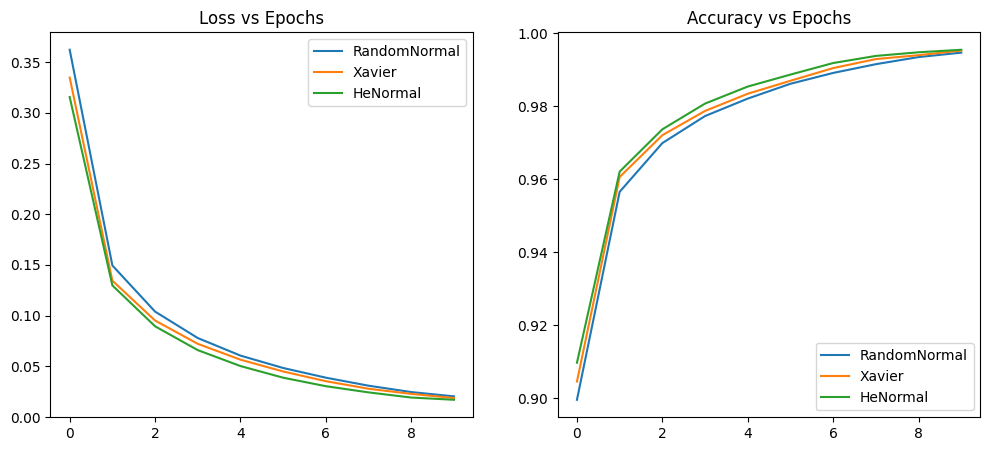

In [ ]:
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
for name in histories:
    plt.plot(histories[name].history['loss'], label=name)
plt.title("Loss vs Epochs")
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
for name in histories:
    plt.plot(histories[name].history['accuracy'], label=name)
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()


In [ ]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

opt_histories = {}

for name, opt in optimizers.items():
    model = build_model(tf.keras.initializers.HeNormal())

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nTraining with {name} Optimizer...")
    history = model.fit(x_train, y_train, epochs=10, batch_size=128, verbose=0)

    opt_histories[name] = history



Training with SGD Optimizer...

Training with Adam Optimizer...


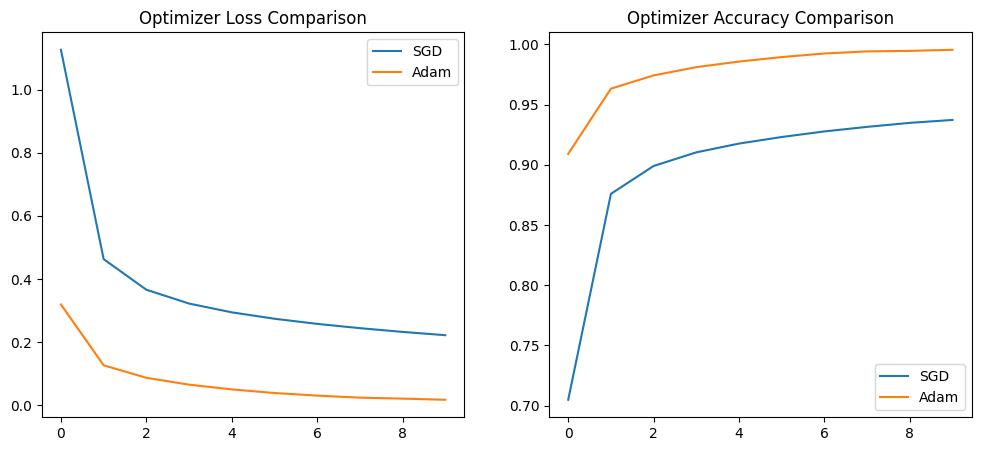

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for name in opt_histories:
    plt.plot(opt_histories[name].history['loss'], label=name)
plt.title("Optimizer Loss Comparison")
plt.legend()

plt.subplot(1,2,2)
for name in opt_histories:
    plt.plot(opt_histories[name].history['accuracy'], label=name)
plt.title("Optimizer Accuracy Comparison")
plt.legend()

plt.show()


In [ ]:
print("\nFinal Accuracy Comparison:")

for name in opt_histories:
    final_acc = opt_histories[name].history['accuracy'][-1]
    print(f"{name}: {final_acc:.4f}")



Final Accuracy Comparison:
SGD: 0.9372
Adam: 0.9955


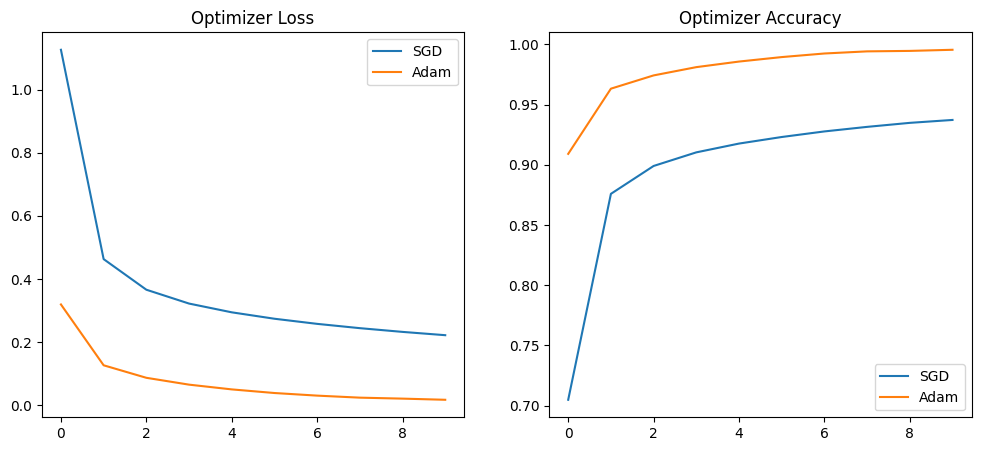

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for name in opt_histories:
    plt.plot(opt_histories[name].history['loss'], label=name)
plt.title("Optimizer Loss")
plt.legend()

plt.subplot(1,2,2)
for name in opt_histories:
    plt.plot(opt_histories[name].history['accuracy'], label=name)
plt.title("Optimizer Accuracy")
plt.legend()

plt.show()
